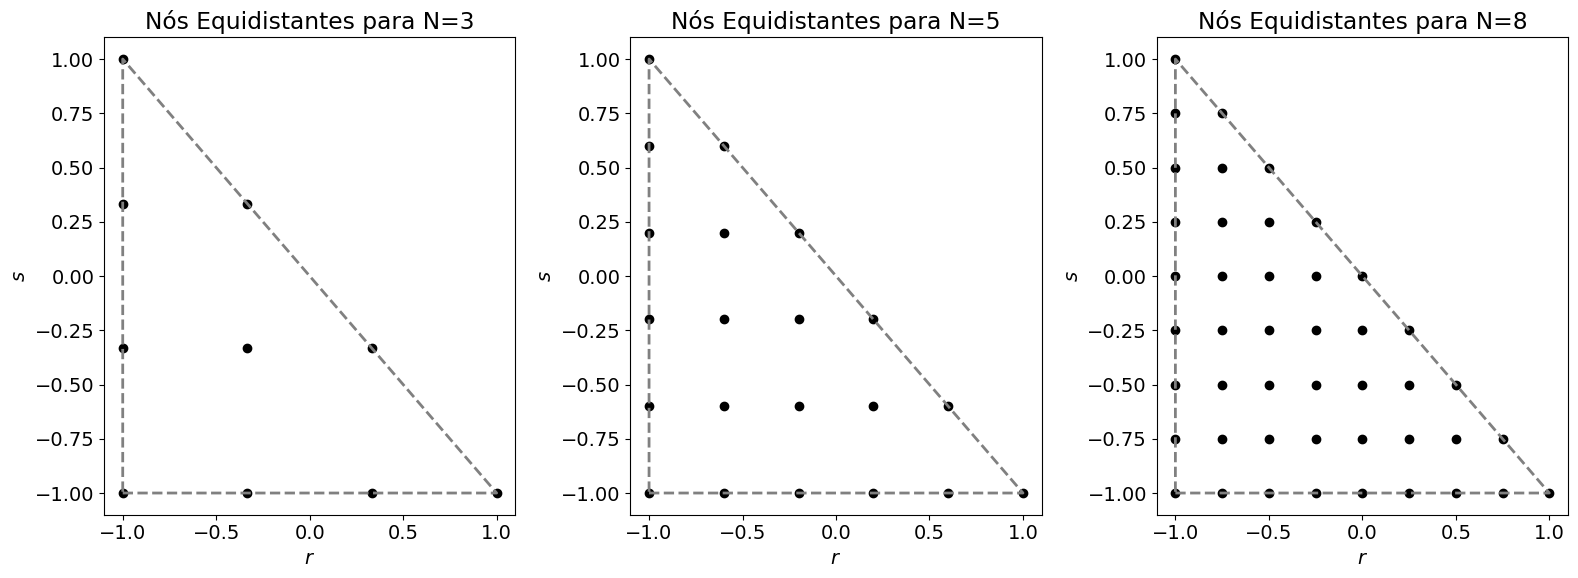

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from scipy.special import eval_jacobi
from scipy.interpolate import BarycentricInterpolator

def equidist_nodes_triangle(N):
    points = []

    for i in range(N + 1):
        for j in range(N + 1 - i):

            # Barycentric coordinates
            l1 = i / N if N > 0 else 0.0
            l2 = j / N if N > 0 else 0.0
            l3 = 1.0 - l1 - l2

            # Triangle vertices
            v1 = np.array([-1.0, -1.0])
            v2 = np.array([ 1.0, -1.0])
            v3 = np.array([-1.0,  1.0])

            # Cartesian coordinates
            p = l1 * v2 + l2 * v3 + l3 * v1
            points.append(p)

    return np.array(points)

def get_gll_nodes(N):
    internal_nodes, _ = scipy.special.roots_jacobi(N - 1, 1, 1)
    r = np.concatenate([[-1.0], internal_nodes, [1.0]]) # elemento de referência
    return r

def blend(a, b, c, alpha):
    num = (4*a*b)**alpha
    den = num + c**alpha
    
    if den == 0: 
        return 0
    
    return num/den

def warped_nodes_triangle(N):
    r_list, s_list = [], []
    
    # configura a função warp
    alpha = 2
    uniform = np.linspace(-1, 1, N+1)
    gll_nodes = get_gll_nodes(N)
    diff_gll_uniform = gll_nodes - uniform
    warp = BarycentricInterpolator(uniform, diff_gll_uniform)
    
    for i in range(N+1):
        for j in range(N - i + 1):
            k=N-i-j
            lambda_1, lambda_2, lambda_3 = i/N, j/N, k/N
            r_eq = 2*lambda_2 - 1
            s_eq = 2*lambda_3 - 1
            
            zeta_1 = lambda_2 - lambda_1 # aresta v1–v2
            zeta_2 = lambda_3 - lambda_2 # aresta v2–v3
            zeta_3 = lambda_1 - lambda_3 # aresta v3–v1
            w1 = warp(zeta_1)
            w2 = warp(zeta_2)
            w3 = warp(zeta_3)
            
            b1 = blend(lambda_1, lambda_2, lambda_3, alpha) # aresta 1
            b2 = blend(lambda_2, lambda_3, lambda_1, alpha) # aresta 2
            b3 = blend(lambda_3, lambda_1, lambda_2, alpha) # aresta 3

            dr = b1 * w1 + b2 * (-w2)
            ds = b2 * w2 + b3 * (-w3)
            
            r_list.append(r_eq + dr)
            s_list.append(s_eq + ds)

    return np.array(r_list), np.array(s_list)

def simplex_2D(i, j, r, s):
    a = 2.0*(1.0 + r)/(1.0 - s) - 1.0
    b=s
    
    # singularidade em s=1 (vértice superior)
    mask = np.abs(s - 1.0) < 1e-12
    a[mask] = -1.0
    h1 = eval_jacobi(i, 0, 0, a)
    h2 = eval_jacobi(j, 2*i+1, 0, b)
    
    return np.sqrt(2.0) * h1 * h2 * (1.0 - b)**i

def vandermonde2D(N, r, s):
    Np = (N+1)*(N+2)//2
    V = np.zeros((len(r), Np))
    col = 0
    for i in range(N+1):
        for j in range(N - i + 1):
            V[:, col] = simplex_2D(i, j, r, s)
            col += 1
    return V

plt.rcParams.update({
    "font.size": 14
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
N_list = [3,5,8]

for i, ax in enumerate(axes.flat):
    # r, s = warped_nodes_triangle(N_list[i])
    # ax.scatter(r, s, c='black')
    
    points = equidist_nodes_triangle(N_list[i])
    ax.scatter(points[:,0], points[:,1], c='black')
    
    tri = np.array([[-1,-1], [1,-1], [-1,1], [-1,-1]])
    ax.plot(tri[:,0], tri[:,1], '--', lw=2, color='gray' )
    ax.set_ylabel(r'$s$')
    ax.set_xlabel(r'$r$')
    ax.set_title(f'Nós Equidistantes para N={N_list[i]}')

plt.tight_layout()
plt.show()